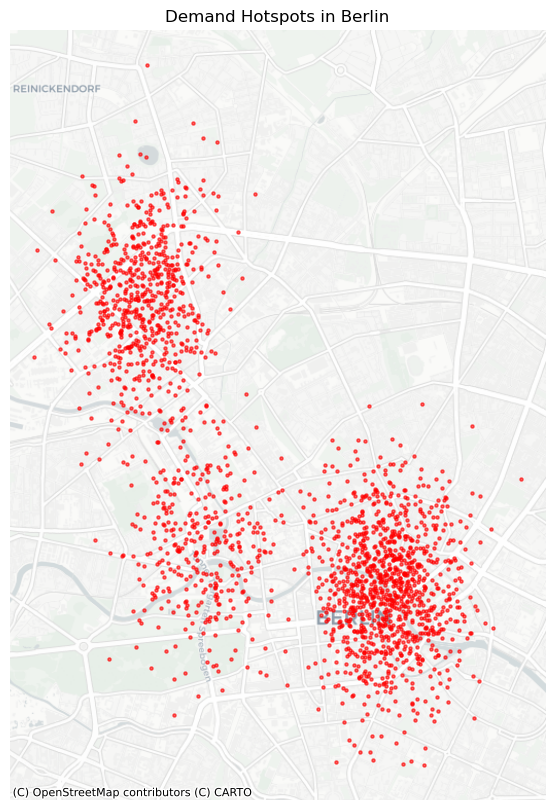

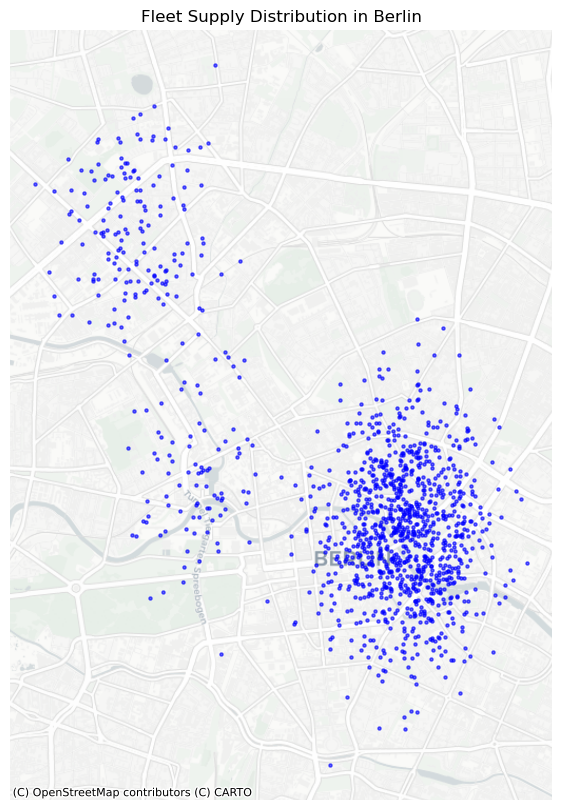

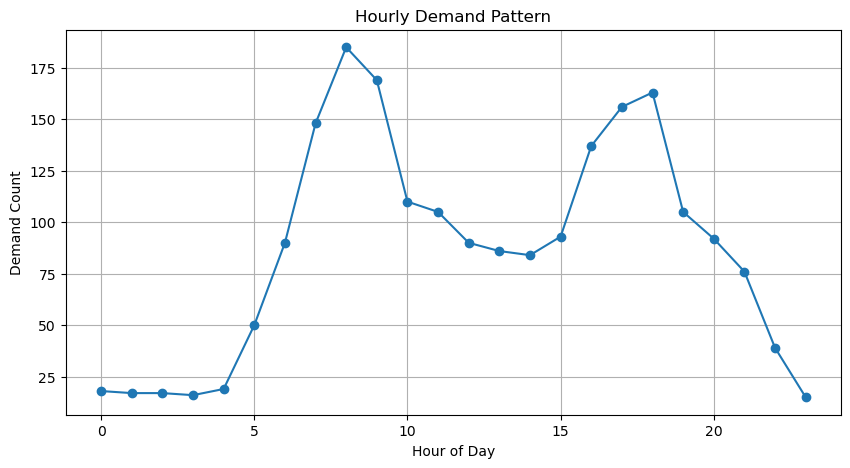

Demand vs Supply Comparison


,area,demand,supply,ratio,status
0,Wedding,660,163,4.049080,undersupplied
1,Hauptbahnhof,250,69,3.623188,undersupplied
2,Brandenburg,323,261,1.237548,balanced
3,Mitte,847,807,1.049566,balanced



Rebalancing Recommendations


""



Project Summary
1. Demand is strongest around Brandenburg and Wedding.
2. Supply is strongest in Mitte, which suggests oversupply.
3. Wedding and Hauptbahnhof show weaker supply relative to demand.
4. A simple rebalancing action is to move vehicles from Mitte to Wedding and Hauptbahnhof.


In [4]:
!pip install pandas numpy geopandas matplotlib shapely contextily
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import contextily as ctx

# -----------------------------
# 1. Setup
# -----------------------------
np.random.seed(42)

# Berlin key areas: lon, lat
areas = {
    "Brandenburg": (13.40, 52.52),
    "Hauptbahnhof": (13.3695, 52.5251),
    "Mitte": (13.4050, 52.5200),
    "Wedding": (13.3600, 52.5500),
}

def generate_points(center_lon, center_lat, n, spread=0.006):
    """
    Generate clustered points around a center.
    """
    return pd.DataFrame({
        "lon": np.random.normal(center_lon, spread, n),
        "lat": np.random.normal(center_lat, spread, n)
    })

def to_gdf(df):
    """
    Convert a DataFrame with lon, lat to GeoDataFrame.
    """
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"
    )
    return gdf.to_crs(epsg=3857)

# -----------------------------
# 2. Simulate demand
# -----------------------------
# High demand in Brandenburg
demand_brandenburg = generate_points(13.40, 52.52, 900)

# Strong demand in Wedding
demand_wedding = generate_points(13.36, 52.55, 650)

# Medium demand in Hauptbahnhof
demand_hbf = generate_points(13.3695, 52.5251, 350)

# Lower demand in Mitte
demand_mitte = generate_points(13.405, 52.52, 180)

demand = pd.concat(
    [demand_brandenburg, demand_wedding, demand_hbf, demand_mitte],
    ignore_index=True
)
demand["type"] = "demand"

# Add hour field for a small time pattern
hours = np.arange(24)
hour_probs = np.array([
    0.01, 0.01, 0.01, 0.01, 0.01, 0.02,
    0.04, 0.07, 0.09, 0.08, 0.06, 0.05,
    0.04, 0.04, 0.04, 0.05, 0.07, 0.09,
    0.08, 0.06, 0.04, 0.03, 0.02, 0.01
])
hour_probs = hour_probs / hour_probs.sum()
demand["hour"] = np.random.choice(hours, size=len(demand), p=hour_probs)

# -----------------------------
# 3. Simulate supply
# -----------------------------
# Oversupply in Mitte
supply_mitte = generate_points(13.405, 52.52, 800)

# Undersupply in Wedding
supply_wedding = generate_points(13.36, 52.55, 160)

# Weak supply in Hauptbahnhof
supply_hbf = generate_points(13.3695, 52.5251, 90)

# Some supply in Brandenburg, but not enough
supply_brandenburg = generate_points(13.40, 52.52, 250)

supply = pd.concat(
    [supply_mitte, supply_wedding, supply_hbf, supply_brandenburg],
    ignore_index=True
)
supply["type"] = "supply"

# -----------------------------
# 4. Assign areas
# -----------------------------
def assign_area(lon, lat):
    # Wedding
    if 13.33 <= lon <= 13.39 and 52.535 <= lat <= 52.565:
        return "Wedding"
    # Hauptbahnhof
    elif 13.355 <= lon <= 13.382 and 52.518 <= lat <= 52.532:
        return "Hauptbahnhof"
    # Mitte
    elif 13.39 <= lon <= 13.42 and 52.512 <= lat <= 52.528:
        return "Mitte"
    # Brandenburg
    else:
        return "Brandenburg"

demand["area"] = demand.apply(lambda row: assign_area(row["lon"], row["lat"]), axis=1)
supply["area"] = supply.apply(lambda row: assign_area(row["lon"], row["lat"]), axis=1)

# -----------------------------
# 5. Convert to GeoDataFrames
# -----------------------------
demand_gdf = to_gdf(demand)
supply_gdf = to_gdf(supply)

# -----------------------------
# 6. Demand map
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 10))
demand_gdf.plot(ax=ax, color="red", markersize=5, alpha=0.6)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title("Demand Hotspots in Berlin")
ax.set_axis_off()
plt.show()

# -----------------------------
# 7. Supply map
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 10))
supply_gdf.plot(ax=ax, color="blue", markersize=5, alpha=0.6)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title("Fleet Supply Distribution in Berlin")
ax.set_axis_off()
plt.show()

# -----------------------------
# 8. Hourly demand chart
# -----------------------------
hourly = demand.groupby("hour").size().reset_index(name="trip_count")

plt.figure(figsize=(10, 5))
plt.plot(hourly["hour"], hourly["trip_count"], marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Demand Count")
plt.title("Hourly Demand Pattern")
plt.grid(True)
plt.show()

# -----------------------------
# 9. Demand vs supply comparison
# -----------------------------
demand_count = demand.groupby("area").size().reset_index(name="demand")
supply_count = supply.groupby("area").size().reset_index(name="supply")

comparison = demand_count.merge(supply_count, on="area", how="outer").fillna(0)
comparison["ratio"] = comparison["demand"] / comparison["supply"].replace(0, 1)

def classify_area(ratio):
    if ratio >= 2.0:
        return "undersupplied"
    elif ratio <= 0.8:
        return "oversupplied"
    else:
        return "balanced"

comparison["status"] = comparison["ratio"].apply(classify_area)
comparison = comparison.sort_values("ratio", ascending=False).reset_index(drop=True)

print("Demand vs Supply Comparison")
display(comparison)

# -----------------------------
# 10. Rebalancing recommendations
# -----------------------------
undersupplied = comparison[comparison["status"] == "undersupplied"].copy()
oversupplied = comparison[comparison["status"] == "oversupplied"].copy()

recommendations = []

for _, under_row in undersupplied.iterrows():
    needed = max(10, int((under_row["demand"] - under_row["supply"]) * 0.25))
    for _, over_row in oversupplied.iterrows():
        available = max(10, int((over_row["supply"] - over_row["demand"]) * 0.15))
        move = min(needed, available)
        if move > 0:
            recommendations.append({
                "from_area": over_row["area"],
                "to_area": under_row["area"],
                "suggested_vehicle_move": move
            })

recommendations_df = pd.DataFrame(recommendations)

print("\nRebalancing Recommendations")
display(recommendations_df)

# -----------------------------
# 11. Final text summary
# -----------------------------
print("\nProject Summary")
print("1. Demand is strongest around Brandenburg and Wedding.")
print("2. Supply is strongest in Mitte, which suggests oversupply.")
print("3. Wedding and Hauptbahnhof show weaker supply relative to demand.")
print("4. A simple rebalancing action is to move vehicles from Mitte to Wedding and Hauptbahnhof.")